In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [5]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
train_raw = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
test_raw = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=COLS, engine="python")
rul_test = pd.read_csv(DATA_DIR / "RUL_FD001.txt", header=None, names=["RUL"]).squeeze("columns").values

In [6]:
DROP = ["op_1", "op_2", "op_3", "s_1", "s_5", "s_6", "s_10", "s_16", "s_18", "s_19"]
SENSORS = [c for c in COLS if c.startswith("s_") and c not in DROP]
print(f"Using {len(SENSORS)} sensors: {SENSORS}")

Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [7]:
RUL_CAP = 125
WINDOW = 15
 
def add_rul(df):
    df = df.copy()
    df["RUL"] = df.groupby("unit").cycle.transform("max") - df.cycle
    df["RUL_capped"] = df["RUL"].clip(upper=RUL_CAP)
    return df
 
def build_features(df, sensors, window):
    """Per-unit rolling stats (mean, std, slope) + raw values + cycle."""
    out = [df[["unit", "cycle"] + sensors].copy()]
    g = df.groupby("unit")[sensors]
    roll = g.rolling(window, min_periods=1)
    mean = roll.mean().reset_index(level=0, drop=True).add_suffix(f"_m{window}")
    std = roll.std().reset_index(level=0, drop=True).fillna(0).add_suffix(f"_sd{window}")
    out += [mean, std]
 
    # Linear-fit slope over window (per unit)
    def slope(x):
        n = len(x)
        if n < 2:
            return 0.0
        t = np.arange(n)
        return np.polyfit(t, x, 1)[0]
    slopes = g.rolling(window, min_periods=2).apply(slope, raw=True).reset_index(level=0, drop=True)
    slopes = slopes.fillna(0).add_suffix(f"_sl{window}")
    out.append(slopes)
    return pd.concat(out, axis=1)

In [8]:
train = add_rul(train_raw)
X_train_full = build_features(train, SENSORS, WINDOW)
y_train_full = train["RUL_capped"].values
feature_cols = [c for c in X_train_full.columns if c not in ("unit", "cycle")]
print(f"Feature count: {len(feature_cols)}")

Feature count: 56


In [9]:
# Per-unit split: 20 units out of 100 for validation
rng = np.random.default_rng(0)
val_units = rng.choice(np.arange(1, 101), size=20, replace=False)
is_val = X_train_full["unit"].isin(val_units).values
X_tr = X_train_full.loc[~is_val, feature_cols].values
y_tr = y_train_full[~is_val]
X_val = X_train_full.loc[is_val, feature_cols].values
y_val = y_train_full[is_val]
print(f"Train rows: {len(X_tr)}, Val rows: {len(X_val)}  (20 held-out units)")

Train rows: 16300, Val rows: 4331  (20 held-out units)


In [10]:
# ---------- Baseline: Ridge ----------
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, y_tr)
rmse_ridge_val = np.sqrt(mean_squared_error(y_val, ridge.predict(X_val)))
print(f"\nRidge   val RMSE (capped RUL): {rmse_ridge_val:.2f}")


Ridge   val RMSE (capped RUL): 22.00


In [11]:
# ---------- CatBoost ----------
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False,
)
model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
rmse_cb_val = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
print(f"CatBoost val RMSE (capped RUL): {rmse_cb_val:.2f}  "
      f"(best iter: {model.get_best_iteration()})")

CatBoost val RMSE (capped RUL): 17.46  (best iter: 205)


In [12]:
# ---------- Evaluate on official test set ----------
test_feat = build_features(test_raw, SENSORS, WINDOW)
last_rows = test_feat.groupby("unit").tail(1).sort_values("unit")
X_test = last_rows[feature_cols].values
y_test_true = rul_test
 
pred_ridge = np.clip(ridge.predict(X_test), 0, None)
pred_cb = np.clip(model.predict(X_test), 0, None)

In [13]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
def metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "NASA_score": nasa_score(y_true, y_pred),
    }


In [ ]:
# Because CatBoost was trained on capped RUL, its predictions are bounded by 125
# in high-life regions. Compare against *true* (uncapped) test RUL — fair since
# cap only suppresses the flat early-life region.

In [14]:
print("\n" + "=" * 72)
print("OFFICIAL TEST SET (100 units, last observation → predict RUL)")
print("=" * 72)
results = pd.DataFrame({
    "Ridge": metrics(y_test_true, pred_ridge),
    "CatBoost": metrics(y_test_true, pred_cb),
}).T
print(results.round(2).to_string())
print("""
Reference (published benchmarks on FD001, test RMSE):
  - Random Forest ~31,   SVR ~20,   CNN-LSTM ~12-15
  - A decent tabular model on FD001 lands around RMSE 15-20.""")


OFFICIAL TEST SET (100 units, last observation → predict RUL)
           RMSE    MAE  NASA_score
Ridge     20.43  16.33     1001.31
CatBoost  16.77  12.00      642.75

Reference (published benchmarks on FD001, test RMSE):
  - Random Forest ~31,   SVR ~20,   CNN-LSTM ~12-15
  - A decent tabular model on FD001 lands around RMSE 15-20.


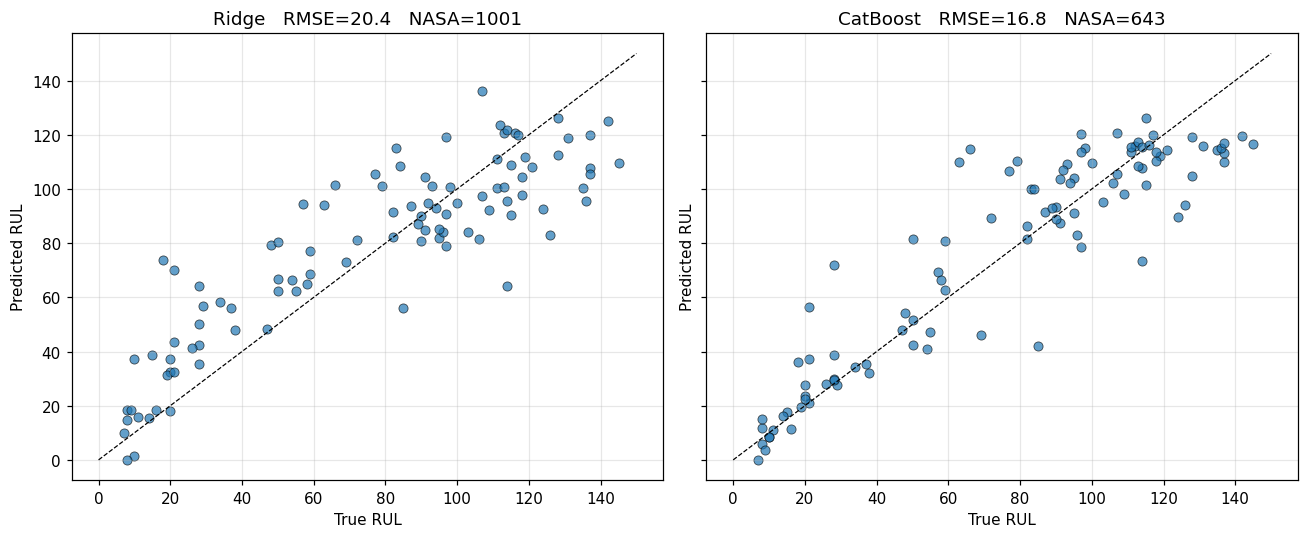

In [15]:
# ---------- Plots ----------
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
# Scatter true vs predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (name, pred) in zip(axes, [("Ridge", pred_ridge), ("CatBoost", pred_cb)]):
    ax.scatter(y_test_true, pred, alpha=0.7, edgecolor="black", lw=0.5)
    lim = max(y_test_true.max(), pred.max()) + 5
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    r = metrics(y_test_true, pred)
    ax.set_title(f"{name}   RMSE={r['RMSE']:.1f}   NASA={r['NASA_score']:.0f}")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "12_rul_scatter.png", bbox_inches="tight")
plt.show()
plt.close()

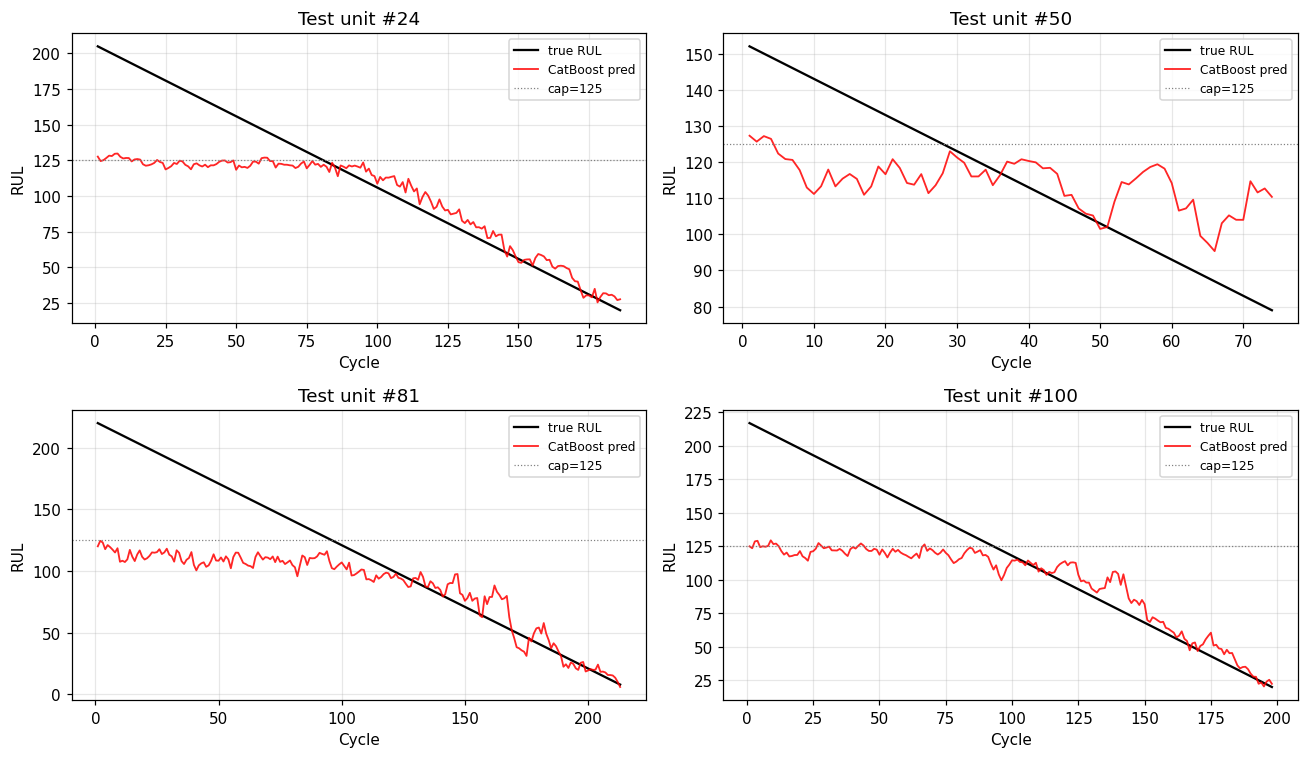

In [16]:
# Prediction trajectory for 4 sample units over their full test history
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sample_units = [24, 50, 81, 100]
for ax, u in zip(axes.flat, sample_units):
    sub = test_feat[test_feat.unit == u].sort_values("cycle")
    true_rul = rul_test[u - 1] + (sub["cycle"].max() - sub["cycle"].values)
    pred_cb_traj = np.clip(model.predict(sub[feature_cols].values), 0, None)
    ax.plot(sub["cycle"], true_rul, "k-", label="true RUL", lw=1.5)
    ax.plot(sub["cycle"], pred_cb_traj, "r-", label="CatBoost pred", lw=1.2, alpha=0.85)
    ax.axhline(RUL_CAP, color="gray", ls=":", lw=0.8, label=f"cap={RUL_CAP}")
    ax.set_title(f"Test unit #{u}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(IMG_DIR / "13_rul_trajectories.png", bbox_inches="tight")
plt.show()
plt.close()

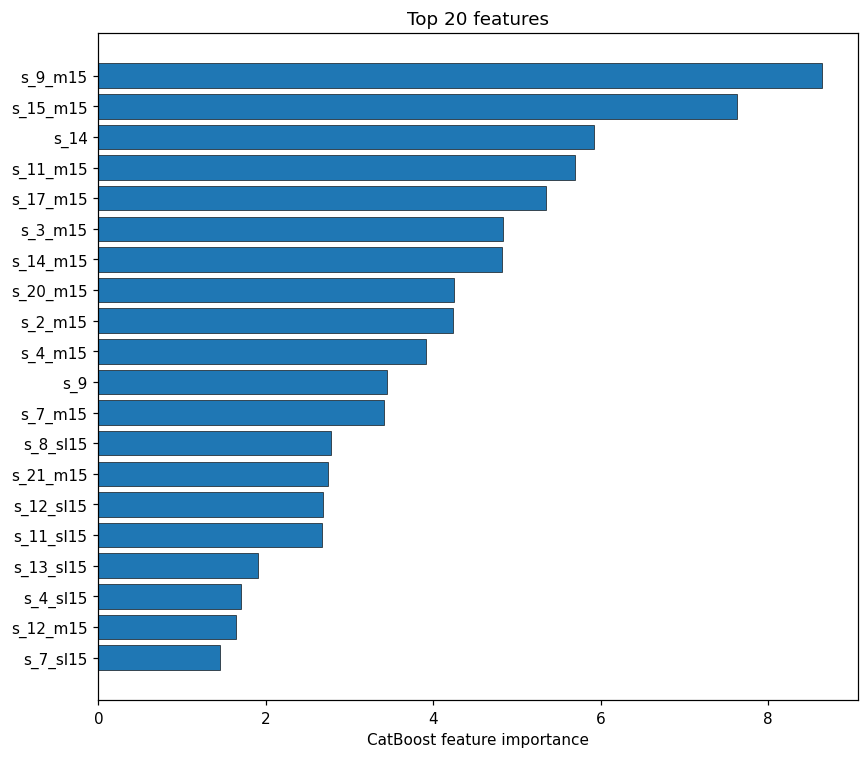

In [17]:
# Feature importance (top 20)
imp = pd.Series(model.get_feature_importance(), index=feature_cols).sort_values()
top20 = imp.tail(20)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20.values, color="tab:blue", edgecolor="black", lw=0.4)
ax.set_xlabel("CatBoost feature importance")
ax.set_title("Top 20 features")
plt.tight_layout()
plt.savefig(IMG_DIR / "14_feature_importance.png", bbox_inches="tight")
plt.show()
plt.close()

In [18]:
results.to_csv("rul_metrics.csv")